In [1]:
from unitpackage.database.echemdb import Echemdb
from unitpackage import remote
import matplotlib.pyplot as plt
import os

# Screening Literature Data

The [echemdb community](https://github.com/echemdb/) provides access to a repository containing cyclic voltammetry data for single crystal electrodes.
The data is extracted from the literature using [svgdigitizer](https://echemdb.github.io/svgdigitizer) and is structured based on metadata provided by the authors in the publications.

Downloading and interacting with the database can be performed with the [unitpackage API](https://echemdb.github.io/unitpackage/).

First, load a specific version of the database from a remote location.

In [ ]:
data_url = os.environ.get(
        "ECHEMDB_DATABASE_URL",
        "https://github.com/echemdb/electrochemistry-data/releases/download/0.5.1/data-0.5.1.zip",
    )

In [ ]:
db = Echemdb.from_remote(url=data_url)
db.describe()

{'number of references': 66,
 'number of entries': 274,
 'materials': {'Ag', 'Au', 'Cu', 'Pt', 'Ru'}}

## Filter the database

Filter the database for ionic liquids (ILs).

In [12]:
ildb = db.filter(lambda entry: entry.system.electrolyte.type=='ionic liquid')
ildb.describe()

{'number of references': 21, 'number of entries': 50, 'materials': {'Au'}}

Filter entries containing 'MPPi-TFSI' as sole component of the IL.

In [13]:
def verify_electrolyte(entry, electrolyte):
    if len(entry.system.electrolyte.components) == 1:
        for component in entry.system.electrolyte.components:
            if component.name==electrolyte:
                return True

mppi_db = ildb.filter(lambda entry: verify_electrolyte(entry, electrolyte='MPPi-TFSI'))
mppi_db.describe()

{'number of references': 2, 'number of entries': 2, 'materials': {'Au'}}

Entries within the database are as follows.

In [14]:
mppi_db

[Echemdb('berger_2017_lithium_261_f1_inset'), Echemdb('schuett_2021_electrodeposition_20461_fs1_blue')]

# Plot the entries

Plots can be created directly from the unipackage interface

In [15]:
berger2017 = mppi_db['berger_2017_lithium_261_f1_inset']
berger2017.plot()

In [17]:
schuett2021 = mppi_db['schuett_2021_electrodeposition_20461_fs1_blue']
schuett2021.plot()

# Interprete and Evaluate

Since the reference potentials are not identical, the data can not readily be compared with each other.  
This problem is illustrated by overlaying both curves.

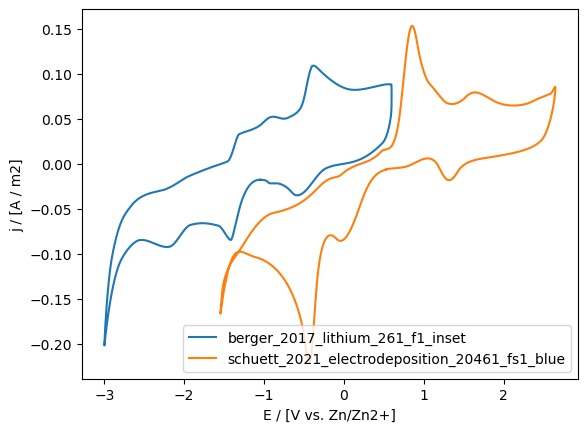

In [20]:
fig, ax = plt.subplots(1,1)

def create_plt_props(entry):
    return {'label':entry.identifier,
            #  'xlabel': 'E / ' + f'[{entry.field_unit("E")} vs. {entry.get_resource("echemdb").schema.get_field("E").custom["reference"]}]',
             'xlabel': 'E / ' + f'[{entry.field_unit("E")} vs. {entry.resource.schema.get_field("E").custom["reference"]}]',
             'ylabel': f'j / [{entry.field_unit("j")}]'}

for entry in mppi_db:
    entry.df.plot('E', 'j', ax=ax, **create_plt_props(entry))

The potential scale from Berger(2017) using a Pt quasi reference electrode can be adjusted such that the largest positive peak overlaps. 

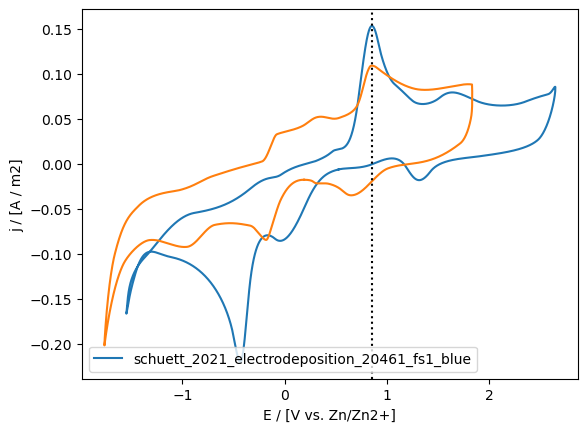

In [21]:
def get_peak_max(entry):
    return entry.df[entry.df['j'] == entry.df['j'].max()]['E'].to_list()[0]

peak_max_berger = get_peak_max(berger2017)
peak_max_schuett = get_peak_max(schuett2021)

E_adjustment = peak_max_schuett - peak_max_berger

fig, ax = plt.subplots(1,1)
schuett2021.df.plot('E', 'j', ax=ax, **create_plt_props(entry))
ax.plot(berger2017.df['E']+E_adjustment, berger2017.df['j'], label=berger2017.identifier)
ax.axvline(peak_max_schuett, ls=':', c='k')

Both CVs do not look identical. The different potential ranges can not be the only cause.

Taking a closer look at the provided electrolyte metadata.

In [23]:
schuett2021.system.electrolyte.components

[{'name': 'MPPi-TFSI', 'proportion': {'unit': 'volume percent', 'value': 100}, 'source': {'supplier': 'IoLiTec', 'purity': {'grade': '>99%'}}, 'purity': {'refinement': 'Vacuum dried at 80°C for 24 h.'}, 'type': 'solvent'}]

In [24]:
berger2017.system.electrolyte.components

[{'name': 'MPPi-TFSI', 'proportion': {'unit': 'volume percent', 'value': 100}, 'source': {'supplier': 'IoLiTec', 'purity': {'grade': '>99%'}}, 'purity': {'refinement': 'Vacuum dried at 80°C for 24 h.'}, 'type': 'solvent'}]

The reported metadata for the electrolyte is also identical. Hence from the available data we can not conclude what is at the origin of the observed differences.